# Customer Churn Prediction & Risk Segmentation Dashboard
## Internship Project — Week 2

## TASK 1 — Data Loading & Exploratory Analysis

In [34]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [35]:

# Load Dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Dataset Shape:", df.shape)
df.head(10)


Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [36]:

# Dataset Information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     5174
Yes    1869
Name: count, dtype: int64


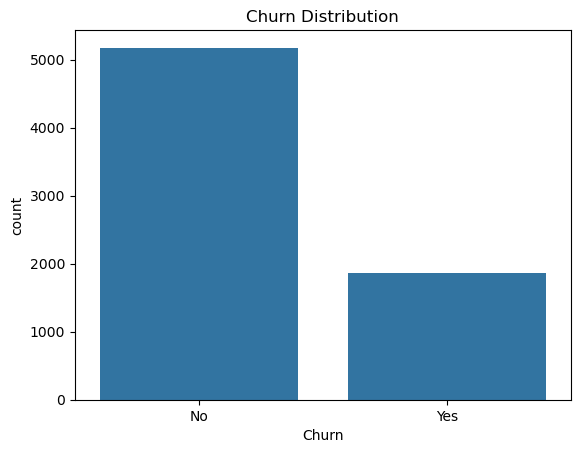

In [37]:

# Target Variable Distribution
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [38]:

# Missing Values
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [40]:

# Summary Statistics
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


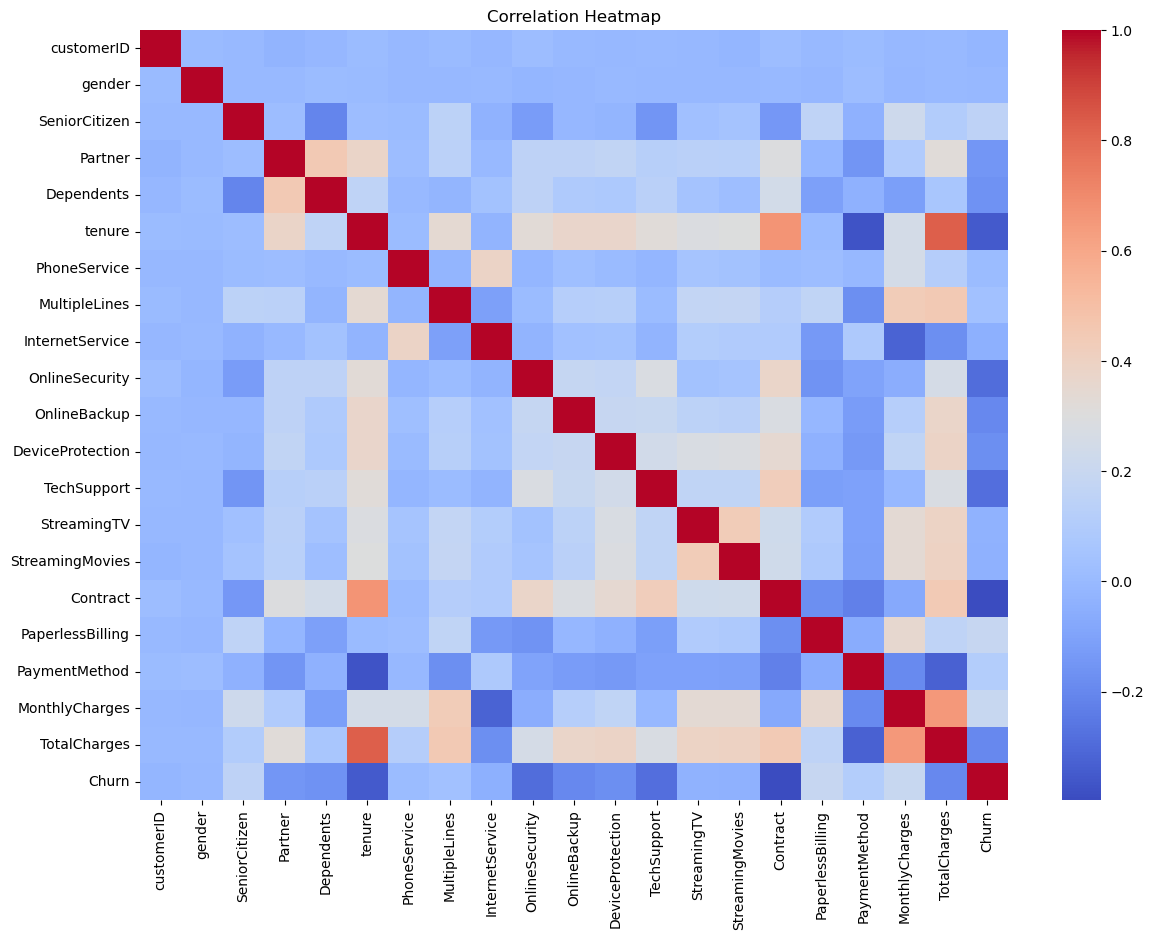

In [41]:

# Correlation Heatmap

temp_df = df.copy()

for col in temp_df.select_dtypes(include='object').columns:
    temp_df[col] = temp_df[col].astype('category').cat.codes

plt.figure(figsize=(14,10))
sns.heatmap(temp_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


## TASK 2 — Data Preprocessing & Feature Engineering

In [42]:

# Drop Customer ID
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Encode target column
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})


In [43]:

# Feature Engineering

df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) &
    (df['TechSupport'] == 'No')
).astype(int)


In [44]:

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,SeniorWithNoSupport,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,0,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,53.985714,0,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,36.050000,0,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,40.016304,0,True,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,50.550000,0,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [45]:

# Split Features and Target

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)


(5634, 32) (1409, 32)


In [46]:

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## TASK 3 — Model Training & Comparison

In [47]:

# Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]


In [48]:

# Random Forest

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]


In [49]:

# Gradient Boosting

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:,1]


In [50]:

# Evaluation Function

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name}")
    print("-"*40)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))


In [51]:

# Evaluate All Models

evaluate_model("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
evaluate_model("Gradient Boosting", y_test, gb_pred, gb_prob)



Logistic Regression
----------------------------------------
Accuracy: 0.808374733853797
Precision: 0.674496644295302
Recall: 0.5374331550802139
F1 Score: 0.5982142857142857
ROC-AUC: 0.8467255676974348

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Random Forest
----------------------------------------
Accuracy: 0.7913413768630234
Precision: 0.6408450704225352
Recall: 0.48663101604278075
F1 Score: 0.5531914893617021
ROC-AUC: 0.8241830065359478

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   m

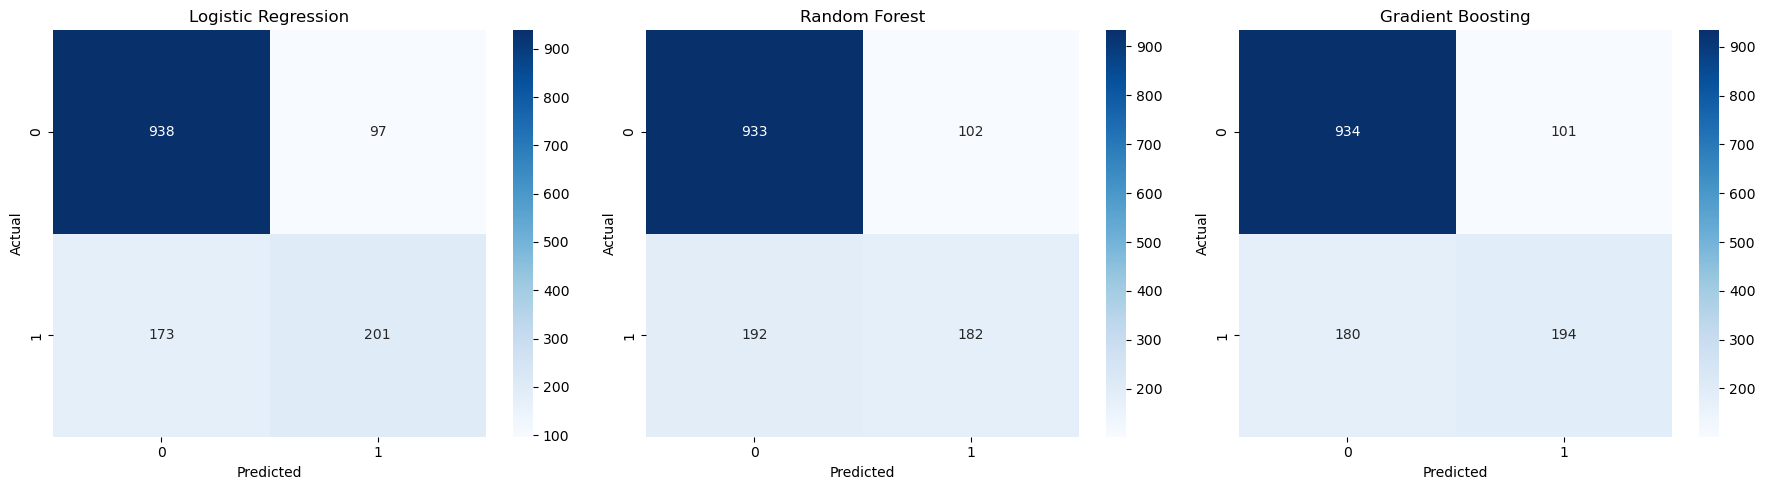

In [52]:

# Confusion Matrices

fig, axes = plt.subplots(1,3, figsize=(18,5))

models = [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred),
    ("Gradient Boosting", gb_pred)
]

for ax, (name, pred) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


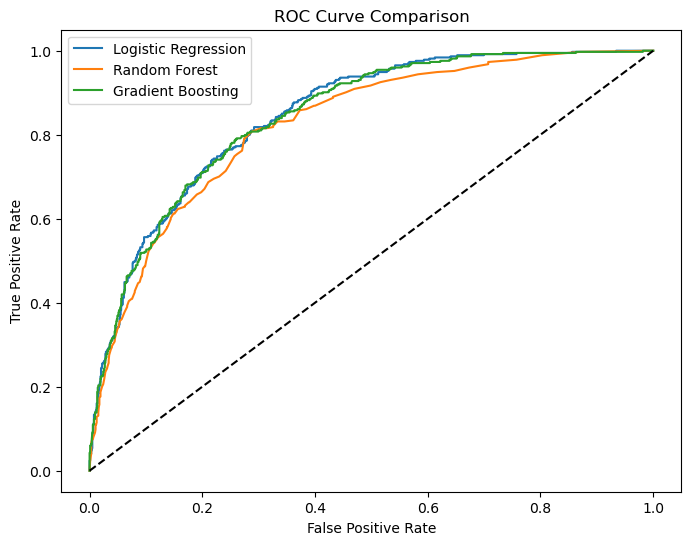

In [53]:

# ROC Curve Comparison

plt.figure(figsize=(8,6))

fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label='Logistic Regression')

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label='Random Forest')

fpr, tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr, label='Gradient Boosting')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("model_comparison.png")
plt.show()


In [ ]:

# Hyperparameter Tuning

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


## TASK 4 — Customer Risk Segmentation

In [ ]:

# Use probabilities from Random Forest

best_probs = rf_prob

def risk_tier(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df = X_test.copy()

risk_df['Churn_Probability'] = best_probs
risk_df['RiskTier'] = risk_df['Churn_Probability'].apply(risk_tier)

risk_df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability,RiskTier
437,0,72,114.05,8468.20,116.002740,0,True,True,True,True,...,False,True,False,True,True,True,False,False,0.00,Low Risk
2280,1,8,100.15,908.55,100.950000,0,False,False,False,True,...,False,True,False,False,True,True,False,False,0.78,High Risk
2235,0,41,78.35,3211.20,76.457143,0,False,True,True,True,...,False,False,True,False,True,True,False,False,0.12,Low Risk
4460,0,18,78.20,1468.75,77.302632,0,True,True,False,True,...,False,False,False,False,False,False,True,False,0.24,Low Risk
3761,0,72,82.65,5919.35,81.086986,0,False,True,False,True,...,False,True,False,True,True,True,False,False,0.00,Low Risk


In [ ]:

# Risk Tier Counts

risk_counts = risk_df['RiskTier'].value_counts()

print(risk_counts)


RiskTier
Low Risk       988
Medium Risk    290
High Risk      131
Name: count, dtype: int64


In [ ]:

# Add important columns back for analysis

original_test = df.iloc[X_test.index]

risk_df['MonthlyCharges'] = original_test['MonthlyCharges']
risk_df['tenure'] = original_test['tenure']

summary = risk_df.groupby('RiskTier')[['MonthlyCharges','tenure']].mean()

summary


,MonthlyCharges,tenure
RiskTier,,
High Risk,78.377863,5.603053
Low Risk,59.103998,39.802632
Medium Risk,74.617069,16.931034


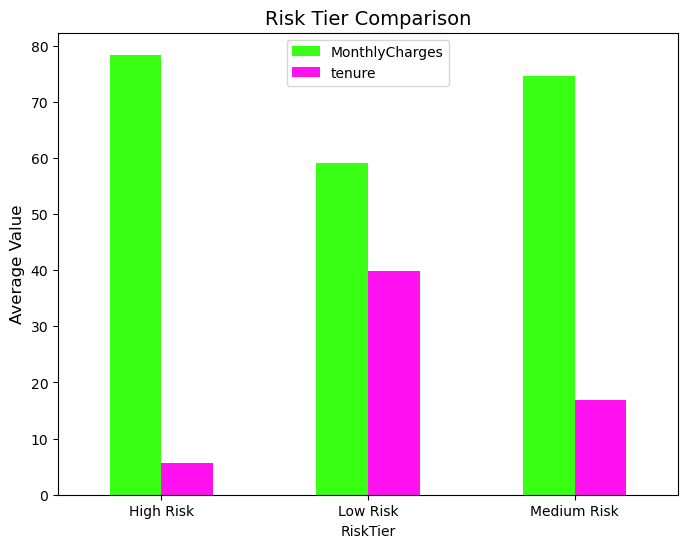

In [ ]:

# Grouped Bar Chart with Neon Colors

summary.plot(
    kind='bar',
    figsize=(8,6),
    color=['#39FF14', '#FF10F0']   # Neon Green & Neon Pink
)

plt.title("Risk Tier Comparison", fontsize=14)
plt.ylabel("Average Value", fontsize=12)
plt.xticks(rotation=0)

plt.show()


## TASK 5 — Visualizations

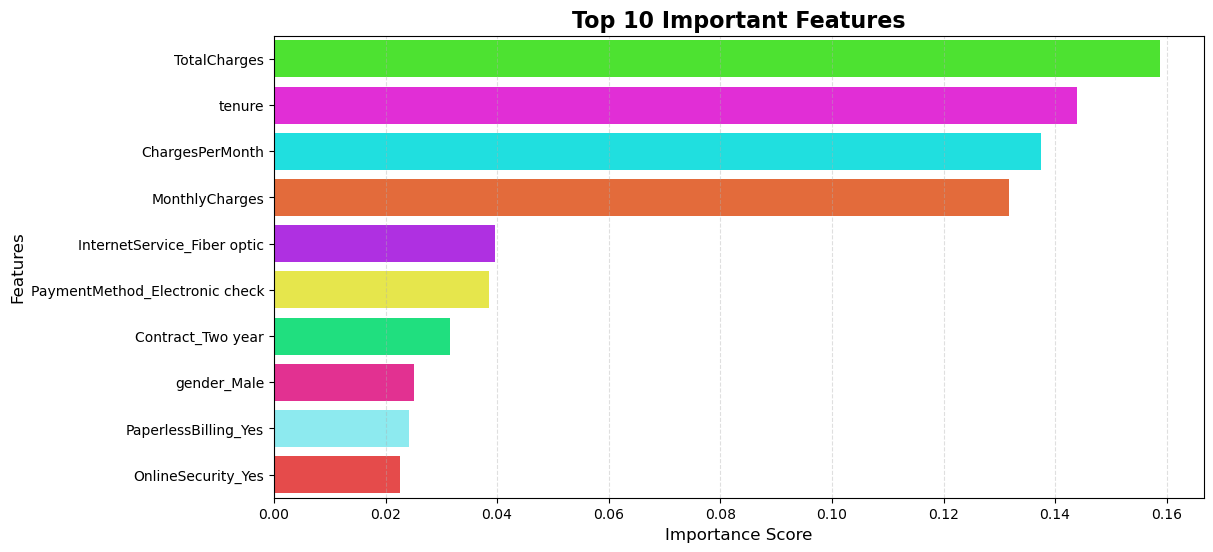

In [ ]:
# Feature Importance with Unique Neon Colors

plt.figure(figsize=(12,6))

neon_colors = [
    '#39FF14',  # Neon Green
    '#FF10F0',  # Neon Pink
    '#00FFFF',  # Cyan
    '#FF5F1F',  # Neon Orange
    '#BC13FE',  # Neon Purple
    '#FFFF33',  # Neon Yellow
    '#00FF7F',  # Spring Green
    '#FF1493',  # Deep Pink
    '#7DF9FF',  # Electric Blue
    '#FF3131'   # Bright Red
]

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance,
    palette=neon_colors
)

plt.title("Top 10 Important Features", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

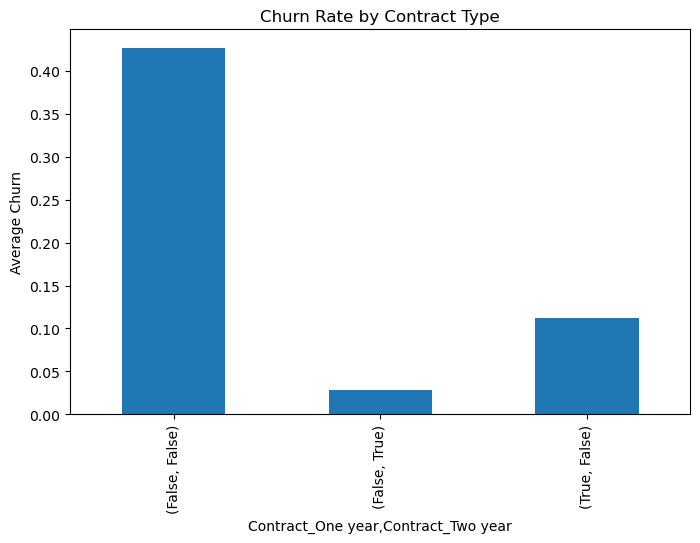

In [ ]:

# Churn Rate by Contract Type

contract_cols = [col for col in df.columns if 'Contract_' in col]

contract_churn = df.groupby(contract_cols)['Churn'].mean()

contract_churn.plot(kind='bar', figsize=(8,5))

plt.title("Churn Rate by Contract Type")
plt.ylabel("Average Churn")

plt.show()


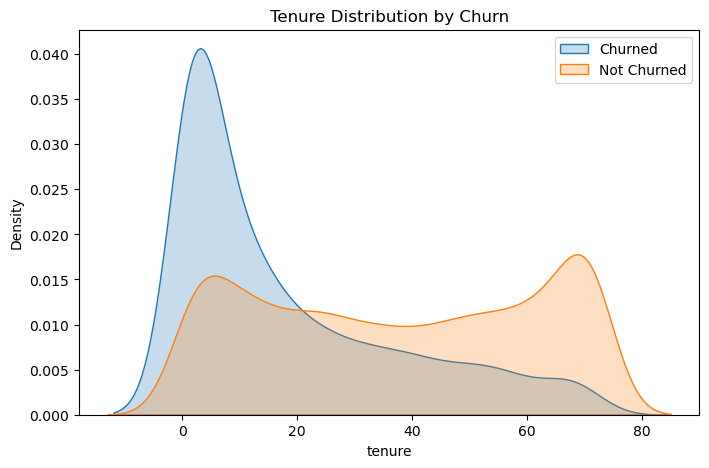

In [ ]:

# Tenure Distribution

plt.figure(figsize=(8,5))

sns.kdeplot(df[df['Churn']==1]['tenure'], label='Churned', fill=True)
sns.kdeplot(df[df['Churn']==0]['tenure'], label='Not Churned', fill=True)

plt.title("Tenure Distribution by Churn")
plt.legend()

plt.show()


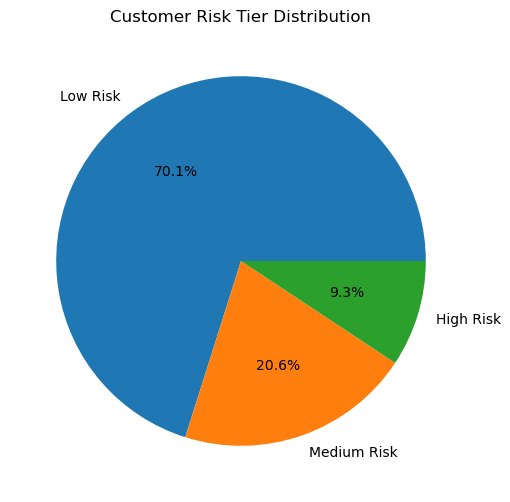

In [ ]:

# Risk Tier Pie Chart

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title("Customer Risk Tier Distribution")

plt.show()


In [ ]:

# Bonus Plotly Visualization

import plotly.express as px

plot_df = original_test.copy()

plot_df['PredictedRisk'] = risk_df['RiskTier'].values

fig = px.scatter(
    plot_df,
    x='MonthlyCharges',
    y='tenure',
    color='Churn',
    title='Monthly Charges vs Tenure'
)

fig.show()


## TASK 6 — Insights & Business Recommendations


### Business Insights

- The Random Forest model performed best because it achieved strong ROC-AUC and balanced precision and recall scores.
- Customers with month-to-month contracts showed the highest churn probability.
- High monthly charges and low tenure were major indicators of customer churn.
- Customers without technical support services were more likely to churn.
- High-risk customers generally had shorter subscription periods and expensive plans.
- Long-term contract customers were more stable and less likely to leave the company.
- The company should offer discounts or loyalty plans to month-to-month customers.
- Improving customer support and onboarding for new customers may reduce churn significantly.
- Personalized retention campaigns can help target high-risk customers before cancellation.
- Additional customer behavior data could further improve model accuracy and prediction quality.
